# Assignment 2: Apartments

In this assignment, we practice some data cleaning by extracting a dataset from HTML files. The original data was scraped from [Booli](https://www.booli.se), but it has been preprocessed so that it is easier for you to extract the relevant information. However, as the data originates from a real-world source that has been put forth by actual people, it contains some errors (e.g., missing fields, data that has been misplaced, otherwise nonsensical information).

The data is provided to you as `gothenburg_sold_apartments.zip`, a zip file that contains 12 HTML files, each corresponding to the final prices as announced by realtors, of apartments sold in a specific year in the Gothenburg region.

## JupyterHub on Minevra

There are two clusters on Minevra that you can use for any assignments, Jupyter and Saturn. If one is busy, please try the other:

1. JupyterHub at Minerva Jupyter cluster: (https://minerva.cse.chalmers.se/jupyter)
2. JupyterHub at Minerva Saturn cluster: (https://minerva.cse.chalmers.se/saturn)

### Choose DAT566 Python Kernel

Switch the kernel by clicking on the kernel name in the top right corner of the notebook, and selecting `DAT566` from the dropdown menu.

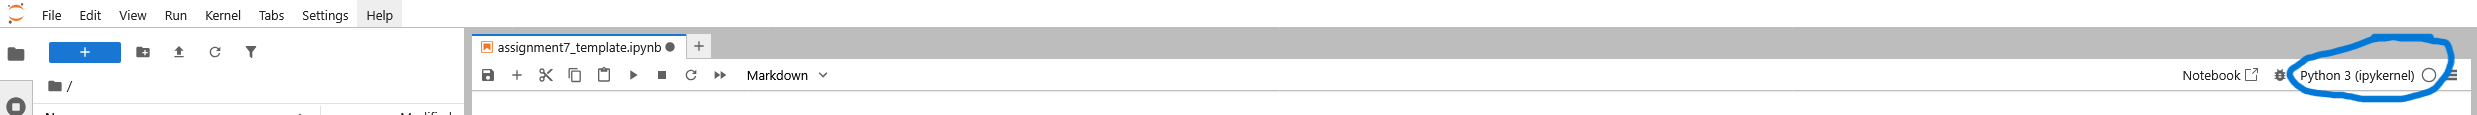

You should see that the kernel name on the right is changed to `DAT566`. Then restart the kernel:

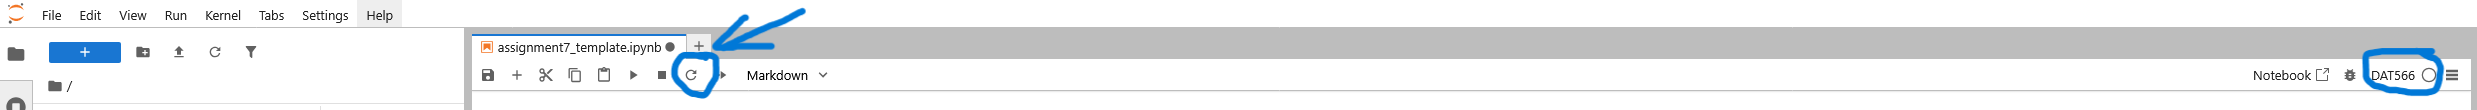

## Question 1

Implement the function `extract_files` below. It should take the name of the zip file as an argument and return a `dict` that maps years (from 2013 to 2024 as `int`s) to the content of the page (as a **string**).

You must decompress the file inside the function; you only have access to the zip file on the grading server, so you cannot use external tools to decompress it.

**Hints:**
- The ZipFile module is very useful here.
- You may assume all HTML files have been encoded in UTF-8.

In [73]:
# Codegrade Tag Question1
# Do *not* remove the tag above
# Implement the extract_files function below
import zipfile

def extract_files(zipfilename):
    """Extract a zip file and return the contents as a dictionary.

    The dictionary returned will have the year as the key (from 2013 
    to 2024) and values are HTML files stored as strings.

    Parameters:
    zipfilename -- name of the zip file to extract
    """
    data = {}

    with zipfile.ZipFile(zipfilename, 'r') as zip:
        for year in range(2013, 2025):
            data[year] = zip.read(f'Gothenburg_sold_apartments_{year}.html').decode('utf-8')
    return data

data = extract_files('gothenburg_sold_apartments.zip')

## Question 2

This is the beef of this assignment. We convert individual HTML files into Pandas dataframes that contain all of the relevant features of an individual announcement as columns. So, there should be one row for each announcement, and the number of columns is fixed.

You will implement the function `extract_announcements`. The function takes the HTML page in as a string. Use Beautiful Soup to extract the information you need, and return a dataframe.

The dataframe shall contain the following columns (with appropriate types indicated in parentheses):
- `address` (string, the address of the object that has been sold)
- `date` (`datetime64`, the date of sale)
- `district` (string, district where the object is located)
- `municipality` (string, municipality where the object is located)
- `price` (numeric, any numerical type should do, prefer `int`, final sales price in SEK)
- `area` (`float`, can contain non-integer values, area of the apartment in m$^2$)
- `rooms` (`float`, can contain non-integer values, the number of rooms in the apartment)
- `floor` (`float`, the floor of the apartment (i.e., which floor it is located in))

Your function must return a dataframe with exactly the columns above and exactly one row per announcement (in the exact order they are listed in the HTML file).

**Some of the features may be missing in some announcements**, you should then leave the field empty in your dataframe. Here are some specifications on how to deal with the data:
- Date should be stored as an appropriate `datetime64` object, use `pd.to_datetime` to create such objects from strings.
- The location is specified with a string that begins *område* (Swedish for *area* or *region*); all relevant announcements should begin with *Lägenhet* (Swedish for *Apartment*), followed by a middle dot. If there are two things separated by middle dot, assume that the first string is the *district*, the second is the *municipality*. If there is only one middle dot, assume it is followed by the municipality. That is, the string `Lägenhet · Biskopsgården · Göteborg` would be interpreted as an apartment whose *district* is *Biskopsgården* and *municipality* is *Göteborg* whereas `Lägenhet · Partille` would be interpreted as an apartment whose *district* is empty and *municipality* is *Partille*.
- Prices are always integer-valued.
- Area is provided in a string that begins with *storlek* (Swedish for *size*). Areas may contain fractions, such a ½. You should convert these to floating points, e.g., *90½* should be converted to `90.5`.
- Rooms are provided in a string that begins with *rum* (Swedish for *room). They may also contain fractions and should be handled like  the area.
- The floor is provided in a string that begins with *våning* (Swedish for *floor*). Floors may also be negtive. Sometimes floors can be non-integers (e.g., `2,5` is to be interpreted as floor number `2.5`). If the floor contains *BV*, it means *bottenvåning* (Swedish for ground floor); this is to be treated as floor number 0.
- Sometimes the strings can come with nonsensical values (e.g., the price per square meter, or the number of rooms in the string that should encode a floor); these should be ignored and the value treated as missing.

You have been provided with a file called `reference_2014.csv`. This shows the desired output for the file matching the year 2014. Your function will be evaluated against other files by the grader.

**Do not call `extract_announcements` yourself in the following cell**. Do your testing in another cell and do not return those cells to the grader. This is because running the function several times can take a long time and it may lead to a timeout.

Your function is expected to provide an *exact* match to the test data.

**Hints:**
- Beautiful Soup is the expected way to parse the HTML.
- Regular expressions are very useful for extracting the information from formatted strings.
- Take care in handling missing values! When you construct the dataframe, the canonical way to represent missing values is with a `None` object or a `nan` floating-point value. Specifically, the values `0.0`, `0`, or `""` are all well-defined values that are **not** missing.

In [ ]:
# Codegrade Tag Question2
# Do *not* remove the tag above
# Implement the extract_announcements function below

import re
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

def extract_announcements(page):
    """
    Extract all announcements from a single page (the entire page is supplied as a string)
    Returns the announcements as a Pandas dataframe.
    The dataframe shall have one row per announcement in the HTML page and the following columns:
    - address
    - date
    - district
    - municipality
    - price
    - area
    - rooms
    - floor

    Parameters:
    page -- content of the HTML page as a string
    """

    soup = BeautifulSoup(page,features='html.parser') # this will suppress a warning about not specifying the default parser
    properties = []

    # Swedish months are not reliably handled by pd.to_datetime directly
    months = {
        'januari': 'January',
        'februari': 'February',
        'mars': 'March',
        'april': 'April',
        'maj': 'May',
        'juni': 'June',
        'juli': 'July',
        'augusti': 'August',
        'september': 'September',
        'oktober': 'October',
        'november': 'November',
        'december': 'December',
    }

    for card in soup.select('div.property-card'):

        title = card.select_one('h3.property-title')
        address = title.get_text(strip=True) if title else None
        property_details = {}

        for paragraph in card.select('div.property-details p'):
            label_element = paragraph.find('strong')

            if label_element is None:
                continue

            label = label_element.get_text(strip=True)
            label = label.rstrip(':').strip().lower()
            value = paragraph.get_text(' ', strip=True)
            value = value[len(label_element.get_text(strip=True)):].strip()
            property_details[label] = value

        date = pd.NaT
        date_text = property_details.get('datum')
        if date_text:
            translated_date = date_text.lower()
            for swedish, english in months.items():
                translated_date = translated_date.replace(swedish, english)
            date = pd.to_datetime(translated_date, errors='coerce')

        district = None
        municipality = None
        location_text = property_details.get('område')
        if location_text:
            locations = [part.strip() for part in location_text.split('·')]
            if locations and locations[0].lower() == 'lägenhet':
                locations = locations[1:]
            if len(locations) == 1:
                municipality = locations[0]
            elif len(locations) >= 2:
                district = locations[0]
                municipality = locations[1]

#===========The following is very much non-scientific nor robust...but it works=============================
        price = np.nan
        price_text = property_details.get('pris')
        if price_text:
            price_match = re.fullmatch(r'\s*(\d[\d\s]*)\s*kr\s*', price_text, flags=re.IGNORECASE)
            if price_match:
                price = int(re.sub(r'\s+', '', price_match.group(1)))

        area = np.nan
        area_text = property_details.get('storlek')
        if area_text:
            area_match = re.fullmatch(r'\s*(\d+(?:½|[,.]\d+)?)\s*m²\s*', area_text, flags=re.IGNORECASE)
            if area_match:
                area_string = (area_match.group(1).replace('½', '.5').replace(',', '.'))
                area = float(area_string)

        rooms = np.nan
        rooms_text = property_details.get('rum')
        if rooms_text:
            rooms_match = re.fullmatch(r'\s*(\d+(?:½|[,.]\d+)?)\s*rum\s*', rooms_text, flags=re.IGNORECASE)
            if rooms_match:
                rooms_string = (rooms_match.group(1).replace('½', '.5').replace(',', '.'))
                rooms = float(rooms_string)

        floor = np.nan
        floor_text = property_details.get('våning')
        if floor_text:
            floor_text = floor_text.strip()
            if re.fullmatch(r'(?:vån(?:ing)?\s*)?BV', floor_text, flags=re.IGNORECASE):
                floor = 0.0
            else:
                floor_match = re.fullmatch(
                    r'(?:vån(?:ing)?\s*)'r'(-?\d+(?:[,.]\d+)?)', floor_text, flags=re.IGNORECASE)
                if floor_match:
                    floor = float(floor_match.group(1).replace(',', '.'))
#===========================================================================================================

        properties.append({
            'address': address,
            'date': date,
            'district': district,
            'municipality': municipality,
            'price': price,
            'area': area,
            'rooms': rooms,
            'floor': floor,
        })

    return pd.DataFrame(properties)

## Question 3

Use your `extract_announcements` and `extract_files` functions to create a dataframe that contains the data from apartment sales in 2023. Store your dataframe in a variable called `df_2023`.

Then, select a subset of the announcements where `municipality` is equal to Göteborg. Store this dataframe as `df_2023_gothenburg`.

This is a separate question for technical reasons.

In [153]:
# Codegrade Tag Question3
# Do *not* remove the tag above
# Write your code below

df_2023 = extract_announcements(data[2023])
df_2023_gothenburg = df_2023[df_2023.municipality == 'Göteborg']

## Question 4

Implement the function `five_point_summary` below. The function should compute a 5-point summary of the values of a Pandas `Series`. That is, an individual column of a dataframe.

The function should return a `Series` object that has the following elements (index should consist of strings corresponding to these elements) in the specified order:
- `min`, the minimum value of the elements in `s`
- `Q1`, the 1st quartile of the elements in `s`
- `median`, the median of the elements in `s`
- `Q3`, the 3rd quartile of the elements in `s`
- `max`, the maximum of the elements in `s`

Use your function to compute the five-point summary of the prices of apartments sold in Gothenburg in 2023, and store the result in `price_2023_gothenburg_fps`.

In [76]:
# Codegrade Tag Question4
# Do *not* remove the tag above
# Implement the function five_point_summary below, and compute the summary for df_2023_gothenburg

def five_point_summary(s):
    """
    Computes the five-point summary of the series s
    Returns a new series that has the following values (as index):
    - min
    - Q1
    - median
    - Q3
    - max

    Parameters:
    s -- The series to compute the summary for
    """

    summary = pd.Series({
        'min': s.min(),
        'Q1': s.quantile(0.25),
        'median': s.median(),
        'Q3': s.quantile(0.75),
        'max': s.max()
    })

    return summary

price_2023_gothenburg_fps = five_point_summary(df_2023_gothenburg.price)

## Question 5

Construct a histogram of apartment prices in Gothenburg in 2023. Use *Sturges' rule* to determine the correct number of bins. Create a new axis object for plotting the histogram and store it in a variable called `ax`. Store your histogram counts and bin thresholds in variables called `counts` and `bins`, respectively. Label axes and give the plot a meaningful title. Set the ticks on the $x$-axis to be in *Millions of kronor* (MSEK). Place the ticks and the tick labels exactly 2.5 MSEK apart, up to and including 20.0 MSEK, with exactly 1 decimal point.

**Hints:**
- You can create a new axis with `plt.subplots()`.
- Calling the `hist()` method of the axis will return the required counts and bin thresholds.
- The number of bins in `counts` should match the correct number of bins as determined by Sturges' rule.
- The number of bin thresholds in `bins` should be exactly one higher: `counts[0]` corresponds to the number of values in the interval from `bins[0]` to `bins[1]` and so on.
- The tick labels should be **exactly** 0.0, 2.5, ..., 20.0.
- The autograder checks technical requirements very strictly because this is in part a technical exercise in producing a plot with given details and characteristics.

[Text(0.0, 0, '0.0'),
 Text(2500000.0, 0, '2.5'),
 Text(5000000.0, 0, '5.0'),
 Text(7500000.0, 0, '7.5'),
 Text(10000000.0, 0, '10.0'),
 Text(12500000.0, 0, '12.5'),
 Text(15000000.0, 0, '15.0'),
 Text(17500000.0, 0, '17.5'),
 Text(20000000.0, 0, '20.0')]

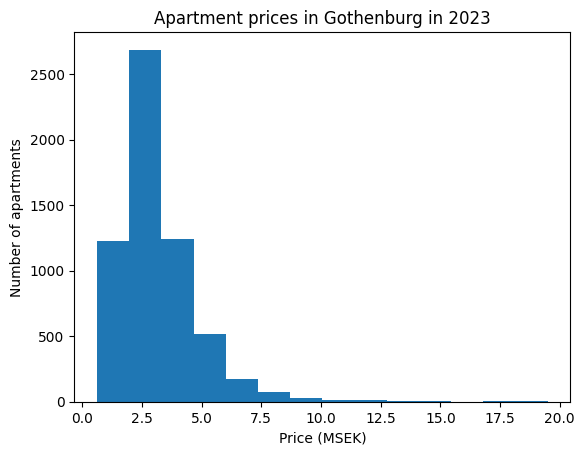

In [87]:
# Codegrade Tag Question5
# Do *not* remove the tag above
# Write your code below

from matplotlib import pyplot as plt

fig, ax = plt.subplots()

n = len(df_2023_gothenburg.price)
bins = int(np.ceil(np.log2(n)+1))
counts, bins, _ = ax.hist(df_2023_gothenburg.price, bins=bins)

ax.set_xlabel('Price (MSEK)')
ax.set_ylabel('Number of apartments')
ax.set_title('Apartment prices in Gothenburg in 2023')
ticks = np.arange(0, 20.1, 2.5)
ax.set_xticks(ticks * 1e6)
ax.set_xticklabels([f"{t:.1f}" for t in ticks])

## Question 6

Create a scatter plot that shows the relationship between the area of the apartment (on the $x$-axis) and the price of the apartment (on the $y$-axis). Add color to your points such that you colorize the apartments by the number of rooms. Label $x$ and $y$ axes and give the plot a title. Also add a legend that shows the relationship between the color and the number of rooms.

Create a new axis object for your plot and call it `ax` again.

**Hints:**
- If you have trouble fitting the legend in the plot, try adjusting the `figsize` parameter of `plt.subplots()`.
- Color can be added to `scatter` with the `c` parameter; the value passed here should have exactly one **integer** color number of reach data point (`x` and `y` coordinates).
- Due to the previous, do note that there are non-integer room counts, so you may need to map, e.g., room counts 1.0, 1.5, 2.0, 2.5, ... to 0, 1, 2, 3, respectively.
- You can extract **legend element handles** from a `scatter` object (the objet returned by `ax.scatter()`) with `scatter.legend_elements()`. You can use this to adjust the labels of your legend.
- The autograder expects that the legend consists of strings `1.0`, `1.5`, `2.0`, ... for the room counts, so please use exactly these strings as legend labels.

In [154]:
df_2023_gothenburg.rooms.unique()

array([1. , 2. , 3. , 4. , 1.5, 5. , 4.5, 2.5, 3.5, 6. , 5.5, nan, 7. ])

Text(0.5, 1.0, 'Apartment area and price in Gothenburg in 2023')

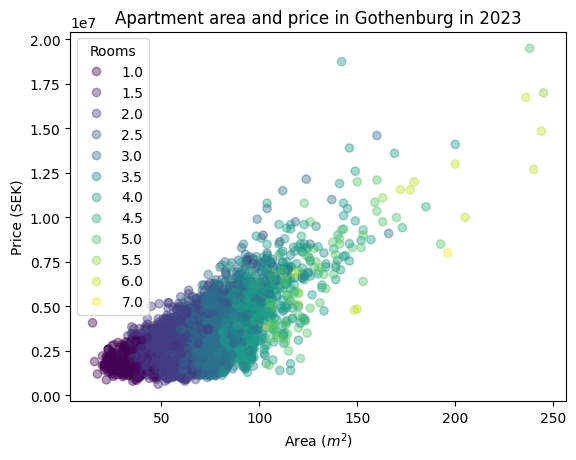

In [ ]:
# Codegrade Tag Question6
# Do *not* remove the tag above
# Write your code below

room_vals = sorted(df_2023_gothenburg.rooms.dropna().unique())
room_map = {room: i for i, room in enumerate(room_vals)}
colors = df_2023_gothenburg.rooms.map(room_map)

fig, ax = plt.subplots()
scatter = ax.scatter(df_2023_gothenburg.area, df_2023_gothenburg.price, c=colors, cmap='viridis', alpha=0.4)

handles, _ = scatter.legend_elements()
ax.legend(handles, [f"{room:.1f}" for room in room_vals], title='Rooms')
ax.set_xlabel('Area ($m^2$)')
ax.set_ylabel('Price (SEK)')
ax.set_title('Apartment area and price in Gothenburg in 2023')

## Question 7

Create a new dataframe called `df_2023_gothenburg_w_psqm` that contains all the same data as `df_2023_gothenburg`, but in addition contains a new column called `price per sqm`. As suggested, this should contain the price per square meter for each apartment sold (that is, the price divided by the area).

In [152]:
# Codegrade Tag Question7
# Do *not* remove the tag above
# Write your code below

df_2023_gothenburg_w_psqm = df_2023_gothenburg.copy()
df_2023_gothenburg_w_psqm['price per sqm'] = df_2023_gothenburg_w_psqm.apply(
    lambda x: x.price/x.area
    if pd.notna(x.area) and x.area > 0
    else np.nan,
    axis=1
)

## Question 8

Create a bar chart where you show average price per square meter conditioned on the number of rooms in the apartment.

That is, there should be one bar for each room count (1.0, 1.5, 2.0, 2.5, ...) that shows the average. However, if there are **no** rooms matching that number of rooms, then there should not be an empty bar (that is, if there are no apartments with 4.5 rooms, the next bar after 4.0 should be simply 5.0).

Label axes and give the plot a title. The $x$ axis ticks should match exactly the number of rooms (just as in the legend of Question 6). That its, there should be one tick per each room, and the tick label should be *exactly* 1.0, 1.5 etc.

Again, create a new axis object and call it `ax`.

**Hints:**
- `groupby` is a useful method.
- Again, the autograder will be super picky about the ticks and tick labels. Make them correct.

Text(0, 0.5, 'Average price per square meter')

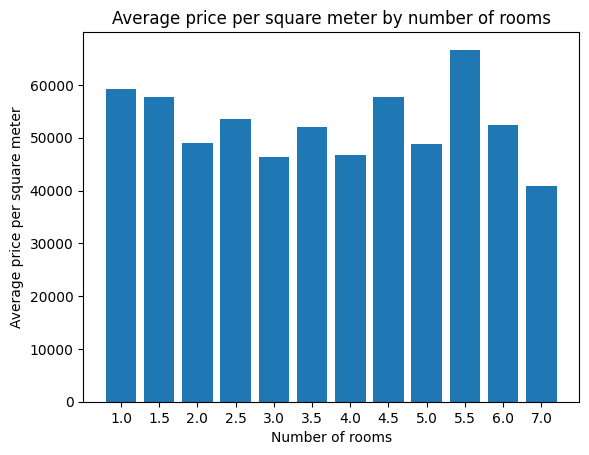

In [111]:
# Codegrade Tag Question8
# Do *not* remove the tag above
# Write your code below

avg_price_per_sqm_by_rooms = df_2023_gothenburg_w_psqm.groupby('rooms')['price per sqm'].mean()

fig, ax = plt.subplots()
ax.bar(avg_price_per_sqm_by_rooms.index.astype(str), avg_price_per_sqm_by_rooms.values)

ax.set_title('Average price per square meter by number of rooms')
ax.set_xlabel('Number of rooms')
ax.set_ylabel('Average price per square meter')

## Question 9

We will do something similar but with the district information in this case. Compute the mean price per square meter **by the district**. Create a `Series` that contains the average price per square meter of the five cheapest districts in a variable called `cheapest`. The Series should have the names of the districts as index and the price as values. Likewise, store a Series of the five most expensive districts in a variable called `most_expensive`.

Then, create a new axis called `ax` and plot a barplot where you show (in ascending order from left to right) the price per square meter in the five cheapest and five most expensive districts. That is, there should be ten such bars in total, and they should become higher towards the right.

Label axes and give the figure a title. Place $x$ ticks below each bar such that it shows which district the bar corresponds to. Make sure that the district names are legible.

**Hints:**
- `groupby()` is again useful
- So is `sort_values`
- The `set_xticks()` function has a parameter called `rotation` that can be useful for making the text legible
- The aforementioned `rotation` parameter is only available if you pass the tick labels at the same time as ticks through `set_xticks`; otherwise, the `rotation` parameter must be passed to `set_xticklabels`

Text(0.5, 1.0, 'Average price per square meter by district')

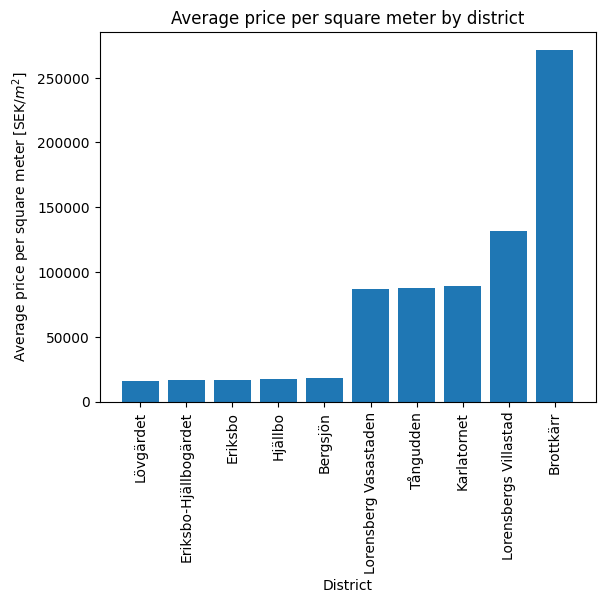

In [132]:
# Codegrade Tag Question9
# Do *not* remove the tag above
# Write your code below

district_means = df_2023_gothenburg_w_psqm.groupby('district')['price per sqm'].mean().sort_values(ascending=True).dropna()
cheapest = district_means[:5]
most_expensive = district_means[-5:]
plotdata = pd.concat([cheapest, most_expensive])

fig, ax = plt.subplots()
plt.bar(plotdata.index, plotdata.values)
plt.xlabel('District')
plt.xticks(plotdata.index, rotation=90)
plt.ylabel('Average price per square meter [SEK/$m^2$]')
plt.title('Average price per square meter by district')

## Question 10

Discuss the findings above. What do they tell us about the housing market in Gothenburg? Which factors influence the prices of apartments, how, and why? Find out about the different districts, for example.

Write 2–4 paragraphs.

*Write your answer here*

In [133]:
avg_room_per_district = df_2023_gothenburg_w_psqm.groupby('district')['rooms'].mean().sort_values(ascending=True).dropna()

The price per square metre differs significantly between districts in Gothenburg, suggesting that location is one of the strongest drivers of apartment values in Gothenburg. However, while larger apartments generally have higher total prices, the price per square metre is more strongly influenced by where the apartment is located than by its size or number of rooms

Affluent central districts such as Vasastaden, Lorensberg and Linnéstaden tend to have the highest prices per square metre, while districts further from the city centre are generally more affordable. This is likely driven by proximity to jobs, universities, public transport, restaurants and other amenities, as well as limited housing supply in attractive central locations

Other analysis also indicates that apartment size does not necessarily increase proportionally with price. Smaller apartments often achieve a higher price per square metre than larger apartments because they are more accessible to buyers and are often located in highly desirable central areas